In [252]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [253]:
df=pd.read_csv('spam.csv', encoding='latin-1')

In [254]:
df.head(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [255]:
df.shape

(5572, 5)

In [256]:
#1.Data cleaning
#2.EDA
#3.text preprocessing
#4.model building
#5.evaluation
#6.improvement
#7.website
#8.deploy

In [257]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [258]:
df.drop(['Unnamed: 2','Unnamed: 3','Unnamed: 4'],axis=1,inplace=True)

In [259]:
df.sample(5)

,v1,v2
5354,ham,Aiyo cos i sms Ì_ then Ì_ neva reply so i wait...
6,ham,Even my brother is not like to speak with me. ...
1120,ham,Cancel cheyyamo?and get some money back?
3112,ham,"Wat time liao, where still got."
1853,ham,I just made some payments so dont have that mu...


In [260]:
df.rename({'v1':'target','v2':'text'},axis=1,inplace=True)

In [261]:
df.sample(5)

,target,text
1340,ham,Might ax well im there.
4596,ham,Full heat pa:-) i have applyed oil pa.
1624,spam,500 free text msgs. Just text ok to 80488 and ...
3084,ham,In da car park
3618,spam,8007 25p 4 Alfie Moon's Children in Need song ...


In [262]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
df['target']=encoder.fit_transform(df['target'])

In [263]:
df.head(5)

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [264]:
df.isnull().sum()

target    0
text      0
dtype: int64

In [265]:
df.duplicated().sum()

np.int64(403)

In [266]:
df=df.drop_duplicates(keep='first')

In [267]:
df.duplicated().sum()

np.int64(0)

In [268]:
df.shape

(5169, 2)

### EDA

In [269]:
df.sample(5)

,target,text
4308,0,He dint tell anything. He is angry on me that ...
5250,1,Urgent! Please call 09061213237 from a landlin...
23,0,Aft i finish my lunch then i go str down lor. ...
858,0,Spoons it is then okay?
2200,0,Haha... can... But i'm having dinner with my c...


In [270]:
df.head(5)

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [271]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

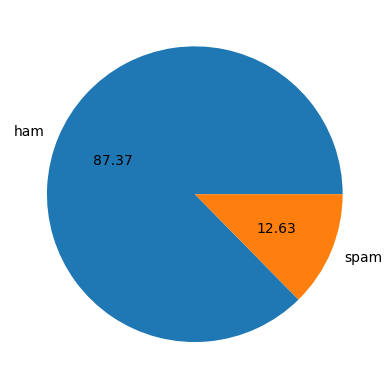

In [272]:
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct="%0.2f")
plt.show()

In [273]:
# Data is imbalanced

In [274]:
import nltk
nltk.download('punkt')

[nltk_data] Error loading punkt: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>


False

In [275]:
df['num_characters']=df['text'].apply(len)

In [276]:
df.head(5)

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [277]:
df['num_words']=df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [278]:
df['num_sentence']=df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [279]:
df.sample(5)

,target,text,num_characters,num_words,num_sentence
644,0,Allo! We have braved the buses and taken on th...,127,28,4
4499,0,Nvm take ur time.,17,5,1
1552,0,U too...,8,3,1
1641,0,"Hi , where are you? We're at and they're not ...",136,39,2
2719,0,Go where n buy? Juz buy when we get there lar.,46,13,2


In [280]:
df[['num_characters','num_words','num_sentence']].describe()

,num_characters,num_words,num_sentence
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [281]:
df[df['target']==0][['num_characters','num_words','num_sentence']].describe()

,num_characters,num_words,num_sentence
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [282]:
df[df['target']==1][['num_characters','num_words','num_sentence']].describe()

,num_characters,num_words,num_sentence
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


<Axes: xlabel='num_characters', ylabel='Count'>

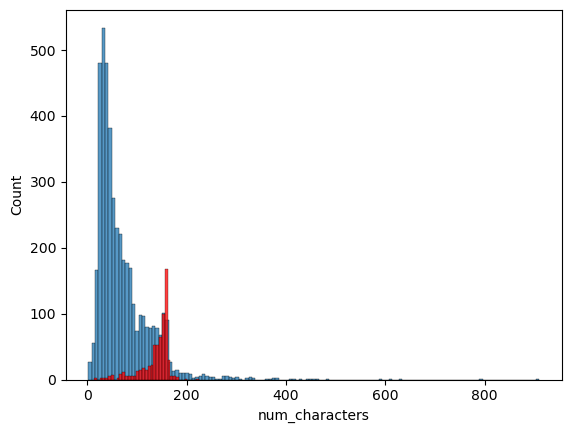

In [283]:
sns.histplot(df[df['target']==0]['num_characters'])
sns.histplot(df[df['target']==1]['num_characters'],color='red')

<Axes: xlabel='num_words', ylabel='Count'>

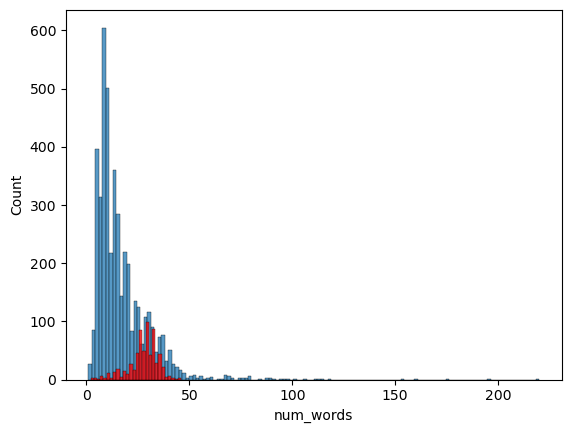

In [284]:
sns.histplot(df[df['target']==0]['num_words'])
sns.histplot(df[df['target']==1]['num_words'],color='red')

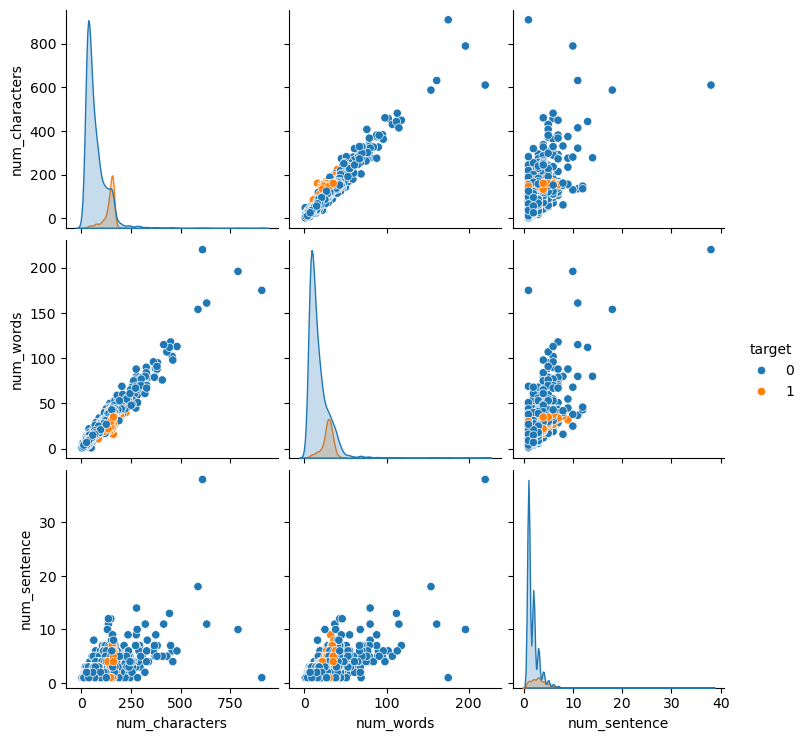

In [285]:
sns.pairplot(df,hue='target')
plt.show()

<Axes: >

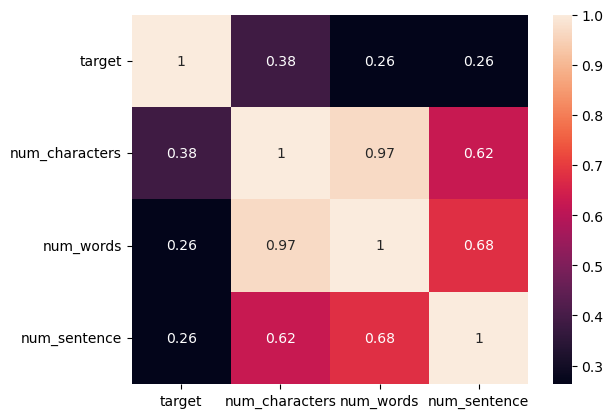

In [286]:

sns.heatmap(df.corr(numeric_only=True),annot=True)

In [287]:
#strong correlation between features so we need to take 1 column

### Data Preprocessing

In [288]:
#lower case
#tokenization
#removing spl char
#remove stopwords
#stemming
from nltk.corpus import stopwords
stopwords.words('english')
import string
string.punctuation
from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()


In [289]:
def transform_text(text):
    text=text.lower()
    text=nltk.word_tokenize(text)#devide word as list
    y=[]
    for i in text:
        if i.isalnum():
            y.append(i)#remove spl char like %,#

    text=y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)#remove stopword and punctuation
    
    text=y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))
        
    return " ".join(y)

    

In [290]:
transform_text('did you like my presentation on my ML?')

'like present ml'

In [291]:
df['transformed_text']=df['text'].apply(transform_text)

In [292]:
#word cloud
!pip install wordcloud
from wordcloud import WordCloud
wc=WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [293]:
spam_wc=wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep=" "))
#concat>cat,sep>separator   or we can use join as well

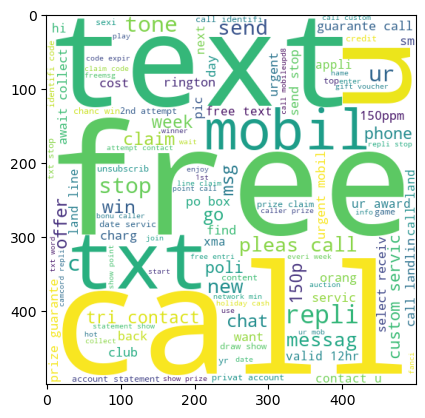

In [294]:
plt.imshow(spam_wc)

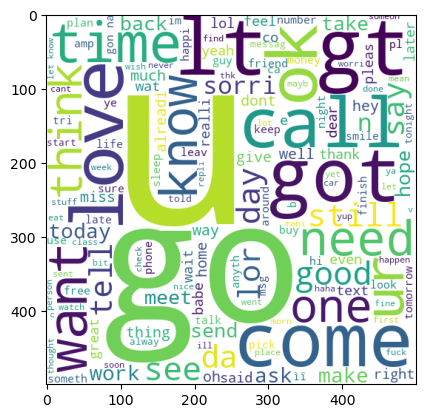

In [295]:
spam_wc=wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep=" "))
plt.imshow(spam_wc)

In [296]:
#top 30 word
spam_corpus=[]
for msg in df[df['target']==1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [297]:
len(spam_corpus)

9939

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29],
 [Text(0, 0, 'call'),
  Text(1, 0, 'free'),
  Text(2, 0, '2'),
  Text(3, 0, 'txt'),
  Text(4, 0, 'text'),
  Text(5, 0, 'u'),
  Text(6, 0, 'ur'),
  Text(7, 0, 'mobil'),
  Text(8, 0, 'stop'),
  Text(9, 0, 'repli'),
  Text(10, 0, 'claim'),
  Text(11, 0, '4'),
  Text(12, 0, 'prize'),
  Text(13, 0, 'get'),
  Text(14, 0, 'new'),
  Text(15, 0, 'servic'),
  Text(16, 0, 'tone'),
  Text(17, 0, 'send'),
  Text(18, 0, 'urgent'),
  Text(19, 0, 'nokia'),
  Text(20, 0, 'contact'),
  Text(21, 0, 'award'),
  Text(22, 0, 'phone'),
  Text(23, 0, 'cash'),
  Text(24, 0, 'pleas'),
  Text(25, 0, 'week'),
  Text(26, 0, 'win'),
  Text(27, 0, 'c'),
  Text(28, 0, 'collect'),
  Text(29, 0, 'min')])

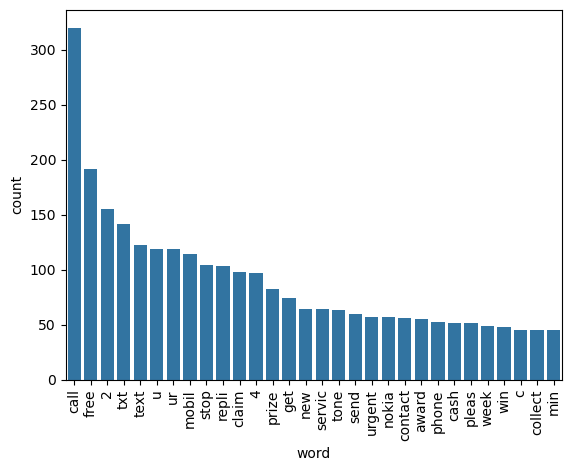

In [298]:
from collections import Counter

top_words=pd.DataFrame(Counter(spam_corpus).most_common(30))
top_words.columns=['word','count']
sns.barplot(x='word', y='count', data=top_words)

plt.xticks(rotation='vertical')


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29],
 [Text(0, 0, 'call'),
  Text(1, 0, 'free'),
  Text(2, 0, '2'),
  Text(3, 0, 'txt'),
  Text(4, 0, 'text'),
  Text(5, 0, 'u'),
  Text(6, 0, 'ur'),
  Text(7, 0, 'mobil'),
  Text(8, 0, 'stop'),
  Text(9, 0, 'repli'),
  Text(10, 0, 'claim'),
  Text(11, 0, '4'),
  Text(12, 0, 'prize'),
  Text(13, 0, 'get'),
  Text(14, 0, 'new'),
  Text(15, 0, 'servic'),
  Text(16, 0, 'tone'),
  Text(17, 0, 'send'),
  Text(18, 0, 'urgent'),
  Text(19, 0, 'nokia'),
  Text(20, 0, 'contact'),
  Text(21, 0, 'award'),
  Text(22, 0, 'phone'),
  Text(23, 0, 'cash'),
  Text(24, 0, 'pleas'),
  Text(25, 0, 'week'),
  Text(26, 0, 'win'),
  Text(27, 0, 'c'),
  Text(28, 0, 'collect'),
  Text(29, 0, 'min')])

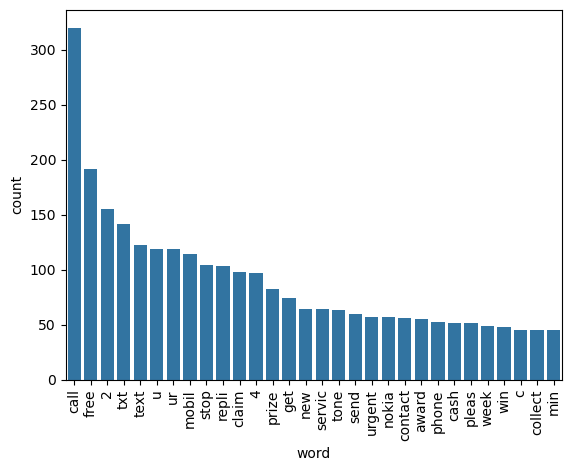

In [299]:
spam_corpus=[]
for msg in df[df['target']==1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

top_words=pd.DataFrame(Counter(spam_corpus).most_common(30))
top_words.columns=['word','count']
sns.barplot(x='word', y='count', data=top_words)

plt.xticks(rotation='vertical')

### Model Building

In [300]:
df

,target,text,num_characters,num_words,num_sentence,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though
...,...,...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161,35,4,2nd time tri 2 contact u pound prize 2 claim e...
5568,0,Will Ì_ b going to esplanade fr home?,37,9,1,b go esplanad fr home
5569,0,"Pity, * was in mood for that. So...any other s...",57,15,2,piti mood suggest
5570,0,The guy did some bitching but I acted like i'd...,125,27,1,guy bitch act like interest buy someth els nex...


In [301]:
# naive based better working naive based

#1st we have to convert text(transformed_text) to number
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv=CountVectorizer()
tfidf=TfidfVectorizer(max_features=3000)
X=cv.fit_transform(df['transformed_text']).toarray()#convert sparse array to dense array
X.shape
y=df['target'].values
y


array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [302]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [303]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [304]:
gnb=GaussianNB()
mnb=MultinomialNB()
bnb=BernoulliNB()

In [305]:
gnb.fit(X_train,y_train)
y_pred1=gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.8684719535783365
[[772 117]
 [ 19 126]]
0.5185185185185185


In [306]:
mnb.fit(X_train,y_train)
y_pred2=mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9738878143133463
[[872  17]
 [ 10 135]]
0.8881578947368421


In [307]:
bnb.fit(X_train,y_train)
y_pred3=bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9661508704061895
[[885   4]
 [ 31 114]]
0.9661016949152542


In [308]:
X1=tfidf.fit_transform(df['transformed_text']).toarray()
X1.shape

(5169, 3000)

In [309]:
y1=df['target'].values
y1

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [310]:
X1_train,X1_test,y1_train,y1_test=train_test_split(X1,y1,test_size=0.2,random_state=42)

In [311]:
gnb.fit(X1_train,y1_train)
y_pred4=gnb.predict(X1_test)
print(accuracy_score(y1_test,y_pred4))
print(confusion_matrix(y1_test,y_pred4))
print(precision_score(y1_test,y_pred4))
mnb.fit(X1_train,y1_train)
y_pred5=mnb.predict(X1_test)
print(accuracy_score(y1_test,y_pred5))
print(confusion_matrix(y1_test,y_pred5))
print(precision_score(y1_test,y_pred5))
bnb.fit(X1_train,y1_train)
y_pred6=bnb.predict(X1_test)
print(accuracy_score(y1_test,y_pred6))
print(confusion_matrix(y1_test,y_pred6))
print(precision_score(y1_test,y_pred6))

0.8607350096711799
[[769 120]
 [ 24 121]]
0.5020746887966805
0.9729206963249516
[[888   1]
 [ 27 118]]
0.9915966386554622
0.9729206963249516
[[884   5]
 [ 23 122]]
0.9606299212598425


In [312]:
#precision score important because data is imbalanced
#tfidf>mnb

In [313]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
!pip install xgboost
from xgboost import XGBClassifier


svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50, random_state=2)
xgb = XGBClassifier(n_estimators=50, random_state=2)

In [314]:
clfs={'SVC':svc,'KN':knc,'DT':dtc,'LR':lrc,'RF':rfc,'AdaBoost':abc,'BgC':bc,'ETC':etc,'GBDT':gbdt,'xgb':xgb}

In [315]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred=clf.predict(X_test)
    accuracy=accuracy_score(y_test,y_pred)
    precision=precision_score(y_test,y_pred)

    return accuracy,precision

In [316]:
accuracy_scores=[]
precision_scores=[]

for name,clf in clfs.items():
    current_accuracy,current_precision=train_classifier(clf,X1_train,y1_train,X1_test,y1_test)

    print("for ",name)
    print("Accuracy - ",current_accuracy)
    print("precision - ",current_precision)

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)
    

for  SVC
Accuracy -  0.97678916827853
precision -  0.9548872180451128
for  KN
Accuracy -  0.9042553191489362
precision -  1.0
for  DT
Accuracy -  0.9342359767891683
precision -  0.8347826086956521
for  LR
Accuracy -  0.9468085106382979
precision -  0.8688524590163934
for  RF
Accuracy -  0.971953578336557
precision -  0.9754098360655737
for  AdaBoost
Accuracy -  0.9158607350096711
precision -  0.8085106382978723
for  BgC
Accuracy -  0.9622823984526112
precision -  0.8840579710144928
for  ETC
Accuracy -  0.9777562862669246
precision -  0.9841269841269841
for  GBDT
Accuracy -  0.9468085106382979
precision -  0.96875
for  xgb
Accuracy -  0.9661508704061895
precision -  0.9435483870967742


In [317]:
performance_df=pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores})

In [318]:
performance_df

,Algorithm,Accuracy,Precision
0,SVC,0.976789,0.954887
1,KN,0.904255,1.000000
2,DT,0.934236,0.834783
3,LR,0.946809,0.868852
4,RF,0.971954,0.975410
5,AdaBoost,0.915861,0.808511
6,BgC,0.962282,0.884058
7,ETC,0.977756,0.984127
8,GBDT,0.946809,0.968750
9,xgb,0.966151,0.943548


### Model Improvement

In [319]:
temp_df=pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_max_ft_3000':accuracy_scores,'Precision_max_ft_3000':precision_scores})

In [320]:
performance_df.merge(temp_df,on='Algorithm')

,Algorithm,Accuracy,Precision,Accuracy_max_ft_3000,Precision_max_ft_3000
0,SVC,0.976789,0.954887,0.976789,0.954887
1,KN,0.904255,1.000000,0.904255,1.000000
2,DT,0.934236,0.834783,0.934236,0.834783
3,LR,0.946809,0.868852,0.946809,0.868852
4,RF,0.971954,0.975410,0.971954,0.975410
5,AdaBoost,0.915861,0.808511,0.915861,0.808511
6,BgC,0.962282,0.884058,0.962282,0.884058
7,ETC,0.977756,0.984127,0.977756,0.984127
8,GBDT,0.946809,0.968750,0.946809,0.968750
9,xgb,0.966151,0.943548,0.966151,0.943548


In [ ]:
#scale and run as naive based work on scaling well

In [ ]:
#adding num ofchar
#votingclassifier (all important equal prior)
#stackingclassifier(weightage)

In [322]:
import pickle

with open('model.pkl', 'wb') as f:
    pickle.dump(mnb, f)